In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils.data_utils import MoonsDataHelper
import warnings
from utils.evaluation_utils import EvaluationHelper
warnings.filterwarnings("ignore")

## Data Visualization

In [2]:
x_train, x_test, y_train, y_test = MoonsDataHelper.load_dataset()
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((1600, 2), (400, 2), (1600,), (400,))

In [3]:
x_train.head()

,Feature_1,Feature_2
1860,1.216889,-0.627630
353,1.216012,-0.401308
1333,-0.617450,1.005901
905,1.625030,-0.216752
1289,0.798015,0.056454


In [4]:
y_train.head()

1860    1
353     1
1333    0
905     1
1289    0
Name: Class_1, dtype: int64

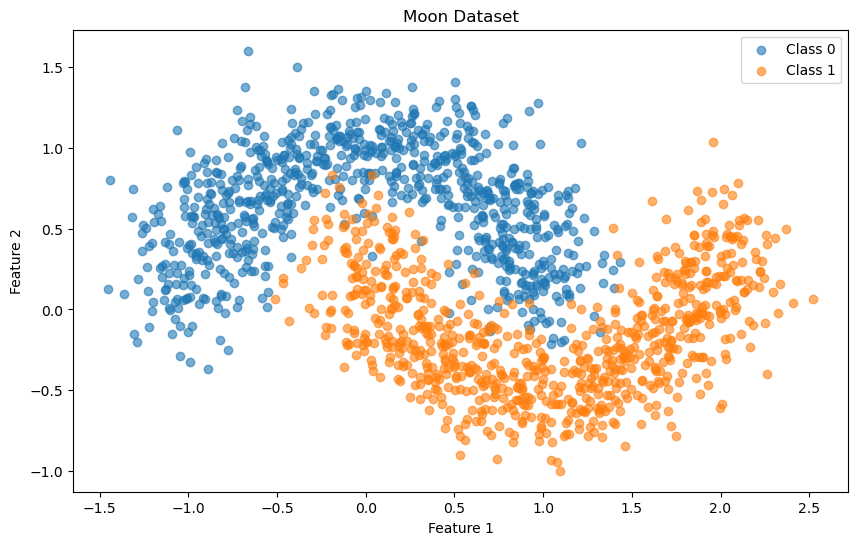

In [5]:
MoonsDataHelper.plot_moons(x_train, y_train)

## Model Training

In [6]:
x_train_class0 = np.array(x_train[y_train == 0])
x_train_class1 = np.array(x_train[y_train == 1])

class0_prior = len(x_train_class0) / len(x_train)
class1_prior = len(x_train_class1) / len(x_train)

x_train_class0_means = np.mean(x_train_class0, axis=0)
x_train_class0_vars = np.var(x_train_class0, axis=0)

x_train_class1_means = np.mean(x_train_class1, axis=0)
x_train_class1_vars = np.var(x_train_class1, axis=0)

priors = {
    0: class0_prior,
    1: class1_prior
}

means = {
    0: x_train_class0_means,
    1: x_train_class1_means
}

variances = {
    0: x_train_class0_vars,
    1: x_train_class1_vars
}

In [7]:
def compute_feature_probability(x, feature_index):
    class0_feature_mean = means[0][feature_index]
    class1_feature_mean = means[1][feature_index]
    
    class0_feature_var = variances[0][feature_index]
    class1_feature_var = variances[1][feature_index]
    
    a1 = 1 / np.sqrt(2 * np.pi * class0_feature_var)
    b1 = (x[feature_index] - class0_feature_mean) ** 2
    c1 = 2 * class0_feature_var
    
    class0_feature_prob = a1 * np.exp(-b1 / c1)
    
    a2 = 1 / np.sqrt(2 * np.pi * class1_feature_var)
    b2 = (x[feature_index] - class1_feature_mean) ** 2
    c2 = 2 * class1_feature_var
    
    class1_feature_prob = a2 * np.exp(-b2 / c2)
    
    return class0_feature_prob, class1_feature_prob

In [8]:
def compute_class_probabilities(x):
    class0_score = np.log(priors[0])
    class1_score = np.log(priors[1])
    
    for feature_index in range(len(x)):
        class0_feature_prob, class1_feature_prob = compute_feature_probability(x, feature_index)
        
        class0_score += np.log(class0_feature_prob)
        class1_score += np.log(class1_feature_prob)
    
    return class0_score, class1_score

In [9]:
def predict(x):
    class0_score, class1_score = compute_class_probabilities(x)
    prediction = class1_score > class0_score
    prob_class1 = 1 / (1 + np.exp(-(class1_score - class0_score)))
    return prediction, prob_class1

## Model Evaluation

In [10]:
predictions = []
probabilities = []

for idx, x in x_test.iterrows():
    prediction, prob_class1 = predict(x)
    predictions.append(prediction)
    probabilities.append(prob_class1)

predictions = np.array(predictions)
probabilities = np.array(probabilities)

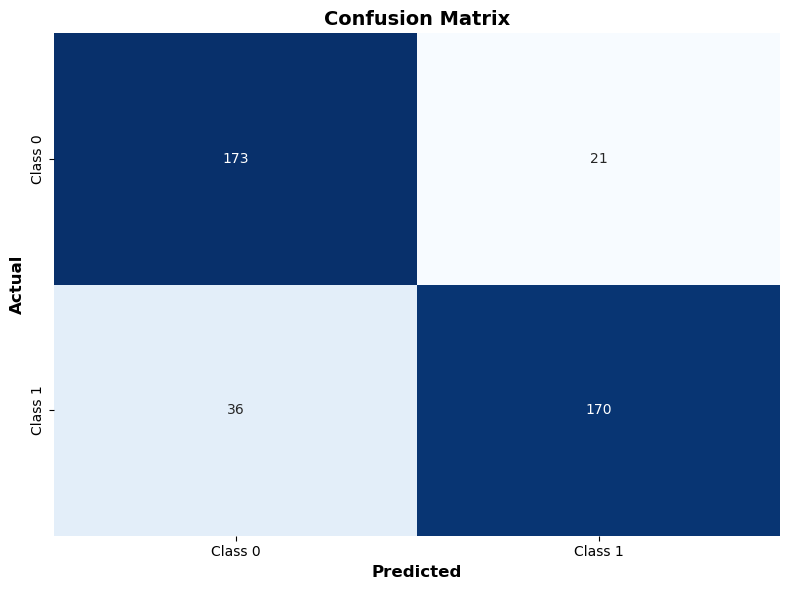

True Negatives: 173
False Positives: 21
False Negatives: 36
True Positives: 170

Sensitivity (Recall): 0.8252
Specificity: 0.8918
Precision: 0.8901
Accuracy: 0.8575
F1 Score: 0.8564


In [11]:
EvaluationHelper.plot_confusion_matrix(y_test, predictions, class_names=["Class 0", "Class 1"])

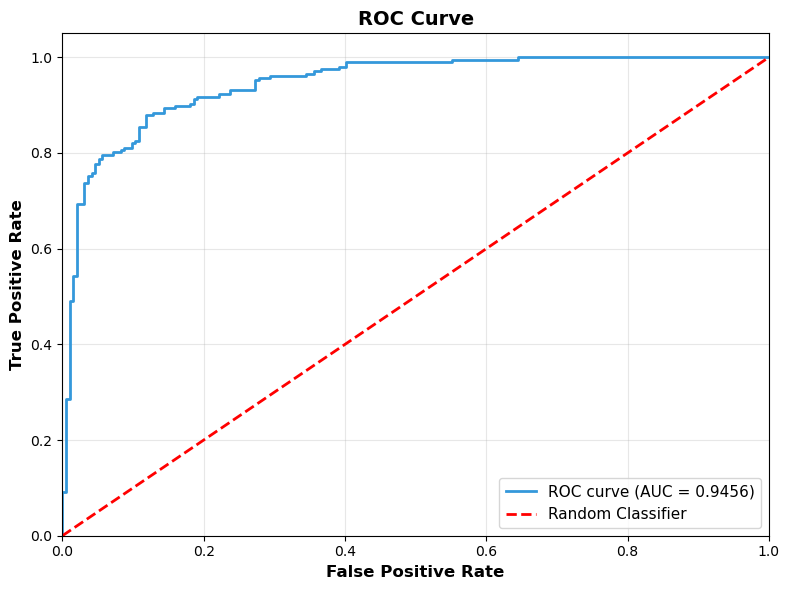

Area Under the Curve (AUC): 0.9456


In [12]:
EvaluationHelper.plot_roc_curve(y_test, probabilities)

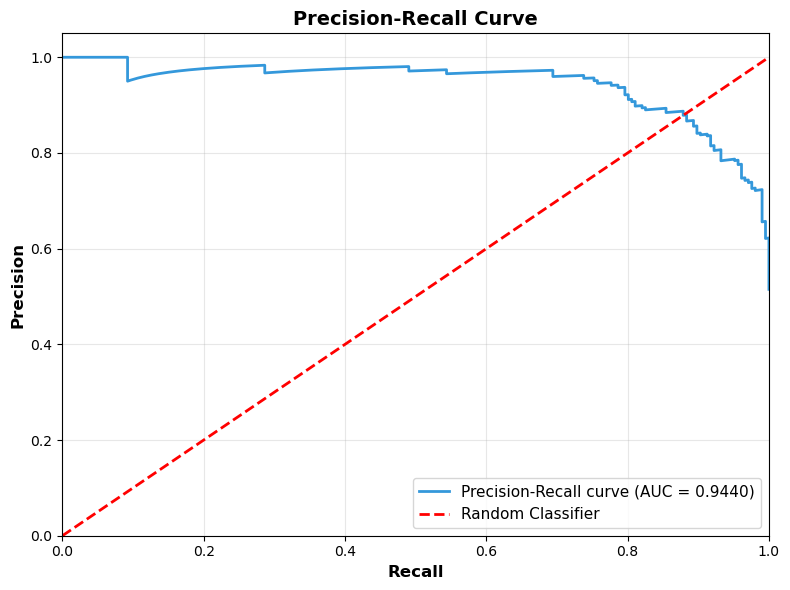

Area Under the Curve (AUC): 0.9440


In [13]:
EvaluationHelper.plot_precision_recall_curve(y_test, probabilities)

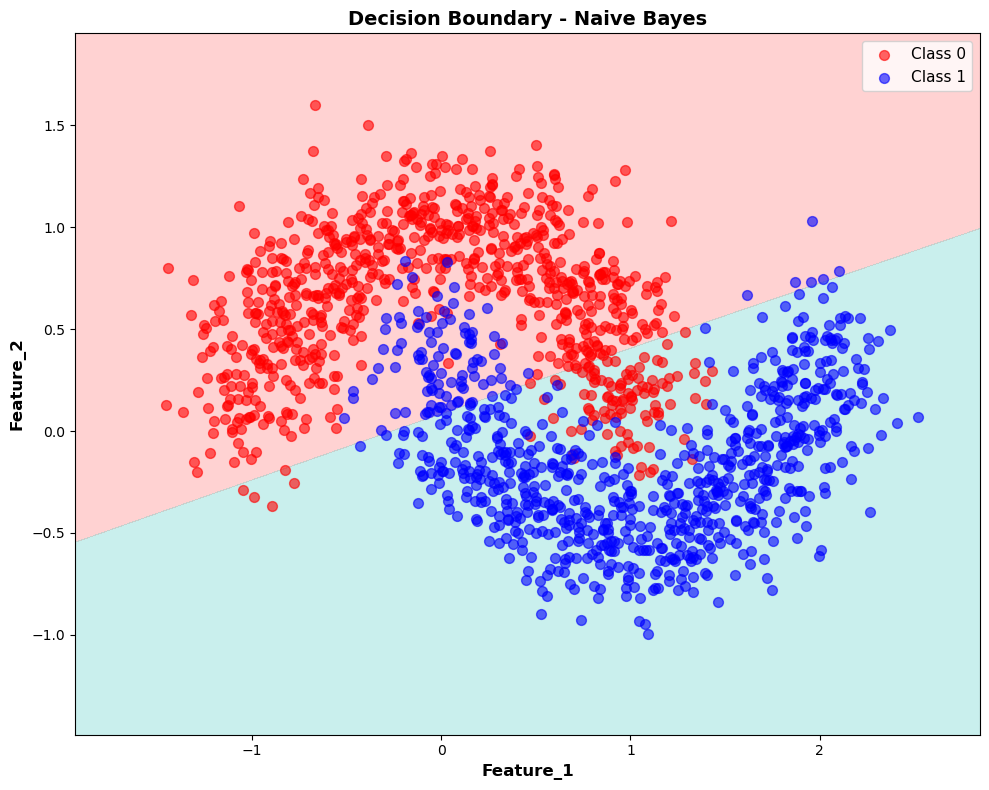

In [14]:
h = 0.02
x_min, x_max = x_test['Feature_1'].min() - 0.5, x_test['Feature_1'].max() + 0.5
y_min, y_max = x_test['Feature_2'].min() - 0.5, x_test['Feature_2'].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = np.array([predict(pd.Series({'Feature_1': xx[i, j], 'Feature_2': yy[i, j]}))[1] 
              for i in range(xx.shape[0]) for j in range(xx.shape[1])])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, levels=[0, 0.5, 1], colors=['#FF6B6B', '#4ECDC4'])
ax.scatter(x_train[y_train == 0]['Feature_1'], x_train[y_train == 0]['Feature_2'], 
           c='red', marker='o', label='Class 0', alpha=0.6, s=50)
ax.scatter(x_train[y_train == 1]['Feature_1'], x_train[y_train == 1]['Feature_2'], 
           c='blue', marker='o', label='Class 1', alpha=0.6, s=50)
ax.set_xlabel('Feature_1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature_2', fontsize=12, fontweight='bold')
ax.set_title('Decision Boundary - Naive Bayes', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()